In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from pathlib import Path

BASE         = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
DATA_WORKING = BASE / 'data' / 'working'
DATA_RAW     = BASE / 'data' / 'raw'
DATA_OUT     = BASE / 'data'
AQR_DIR      = DATA_RAW / 'aqr'

plt.rcParams.update({
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'font.size': 10,
})

TRAIN_START = '2010-01-01'
TRAIN_END   = '2023-12-31'
STAMP_DUTY  = 0.005

def to_month_start(s):
    s = s.copy()
    s.index = pd.to_datetime([str(p) for p in pd.to_datetime(s.index).to_period('M')])
    return s

print('Setup complete.')
print(f'AQR factor directory: {AQR_DIR}')
print(f'  exists: {AQR_DIR.exists()}')
if AQR_DIR.exists():
    print(f'  files:  {[f.name for f in AQR_DIR.glob("*.xlsx")]}')

Setup complete.
AQR factor directory: C:\Users\user\ftse250_study\data\raw\aqr
  exists: True
  files:  ['Betting Against Beta Equity Factors Monthly (1).xlsx', 'Betting Against Beta Equity Factors Monthly (2).xlsx', 'Betting Against Beta Equity Factors Monthly.xlsx', 'The Devil in HMLs Details Factors Monthly (1).xlsx', 'The Devil in HMLs Details Factors Monthly.xlsx']


In [2]:
def load_aqr_sheet(path, sheet_name, country_col='United Kingdom'):
    """
    Read an AQR Excel sheet. AQR files typically have:
      - 18 rows of header/notes
      - row with 'DATE' and country names as columns
      - data below
    Robust to slight variations: tries to find the header row automatically.
    """
    raw = pd.read_excel(path, sheet_name=sheet_name, header=None)

    # Find the header row by searching for 'DATE' or 'Date' in column 0
    header_row = None
    for i in range(min(30, len(raw))):
        cell = str(raw.iloc[i, 0]).strip().lower()
        if cell in ('date', 'dates'):
            header_row = i
            break
    if header_row is None:
        raise ValueError(f'Could not find DATE header row in {path.name} / {sheet_name}')

    # Re-read with the correct header
    df = pd.read_excel(path, sheet_name=sheet_name, header=header_row)
    df = df.rename(columns={df.columns[0]: 'date'})
    df['date'] = pd.to_datetime(df['date'], errors='coerce')
    df = df.dropna(subset=['date'])

    if country_col not in df.columns:
        # AQR sometimes has trailing whitespace; try a fuzzy match
        candidates = [c for c in df.columns if isinstance(c, str) and country_col.lower() in c.lower()]
        if candidates:
            country_col = candidates[0]
            print(f'  Note: using fuzzy-matched column "{country_col}"')
        else:
            raise ValueError(f'Country "{country_col}" not in columns: {list(df.columns)[:10]}...')

    series = df.set_index('date')[country_col].dropna()
    series.index = pd.to_datetime([str(p) for p in series.index.to_period('M')])
    return series.astype(float)


# ── Identify the workbook to read ─────────────────────────────────────────
# AQR files we expect:
#   - Betting Against Beta Equity Factors Monthly.xlsx
#   - The Devil in HMLs Details Factors Monthly.xlsx
# Both contain MKT, SMB, HML, UMD, RF sheets per country.

candidate_files = list(AQR_DIR.glob('*.xlsx'))
print(f'Excel files found: {len(candidate_files)}')
for f in candidate_files:
    print(f'  - {f.name}')

Excel files found: 5
  - Betting Against Beta Equity Factors Monthly (1).xlsx
  - Betting Against Beta Equity Factors Monthly (2).xlsx
  - Betting Against Beta Equity Factors Monthly.xlsx
  - The Devil in HMLs Details Factors Monthly (1).xlsx
  - The Devil in HMLs Details Factors Monthly.xlsx


In [3]:
# ── List sheets in each workbook to choose the right one ──────────────────
for f in candidate_files:
    try:
        xl = pd.ExcelFile(f)
        print(f'\n{f.name}:')
        for s in xl.sheet_names:
            print(f'  - {s}')
    except Exception as e:
        print(f'  Error reading {f.name}: {e}')


Betting Against Beta Equity Factors Monthly (1).xlsx:
  - BAB Factors
  - Definition
  - Data Sources
  - --> Additional Global Factors
  - MKT
  - SMB
  - HML FF
  - HML Devil
  - UMD
  - ME(t-1)
  - RF
  - Sources and Definitions
  - Disclosures

Betting Against Beta Equity Factors Monthly (2).xlsx:
  - BAB Factors
  - Definition
  - Data Sources
  - --> Additional Global Factors
  - MKT
  - SMB
  - HML FF
  - HML Devil
  - UMD
  - ME(t-1)
  - RF
  - Sources and Definitions
  - Disclosures

Betting Against Beta Equity Factors Monthly.xlsx:
  - BAB Factors
  - Definition
  - Data Sources
  - --> Additional Global Factors
  - MKT
  - SMB
  - HML FF
  - HML Devil
  - UMD
  - ME(t-1)
  - RF
  - Sources and Definitions
  - Disclosures

The Devil in HMLs Details Factors Monthly (1).xlsx:
  - HML Devil
  - Definition
  - Data Sources
  - --> Additional Global Factors
  - MKT
  - SMB
  - HML FF
  - UMD
  - ME(t-1)
  - RF
  - Sources and Definitions
  - Disclosures

The Devil in HMLs Details

In [7]:
# ── Load each factor ──────────────────────────────────────────────────────
FACTOR_FILE = candidate_files[0]
print(f'Using: {FACTOR_FILE.name}\n')

# AQR Betting Against Beta workbook uses ISO-3 country codes
SHEET_MAP = {
    'MKT': ('MKT', 'GBR'),
    'SMB': ('SMB', 'GBR'),
    'HML': ('HML FF', 'GBR'),
    'UMD': ('UMD', 'GBR'),
    'RF':  ('RF',  'Risk Free Rate'),
}

factors = {}
for fac, (sheet, col) in SHEET_MAP.items():
    try:
        s = load_aqr_sheet(FACTOR_FILE, sheet, country_col=col)
        factors[fac] = s
        print(f'  {fac:5s}  ({sheet:10s} | {col:20s}): {len(s)} months, '
              f'{s.index.min().strftime("%Y-%m")} -> {s.index.max().strftime("%Y-%m")}, '
              f'mean={s.mean()*100:+.2f}%')
    except Exception as e:
        print(f'  {fac:5s}  FAILED: {e}')

factors_df = pd.DataFrame(factors).dropna()
print(f'\nAligned factor panel: {factors_df.shape[0]} months')
print(factors_df.head())

Using: Betting Against Beta Equity Factors Monthly (1).xlsx

  MKT    (MKT        | GBR                 ): 483 months, 1986-01 -> 2026-03, mean=+0.54%
  SMB    (SMB        | GBR                 ): 453 months, 1988-07 -> 2026-03, mean=-0.20%
  HML    (HML FF     | GBR                 ): 453 months, 1988-07 -> 2026-03, mean=+0.48%
  UMD    (UMD        | GBR                 ): 471 months, 1987-01 -> 2026-03, mean=+1.07%
  RF     (RF         | Risk Free Rate      ): 1197 months, 1926-07 -> 2026-03, mean=+0.27%

Aligned factor panel: 453 months
                 MKT       SMB       HML       UMD        RF
1988-07-01  0.001714 -0.019278  0.081721 -0.003776  0.005467
1988-08-01 -0.074028  0.021058  0.055291  0.010293  0.005792
1988-09-01  0.040387 -0.140996  0.125877  0.020244  0.006083
1988-10-01  0.061347 -0.003197  0.020483 -0.013970  0.006042
1988-11-01  0.007257  0.004978  0.050269  0.010135  0.006133


In [8]:
# ── Sanity check: factor summary stats ────────────────────────────────────
factors_train = factors_df[(factors_df.index >= TRAIN_START) & (factors_df.index <= TRAIN_END)]

summary = pd.DataFrame({
    'Mean (ann %)' : factors_train.mean() * 1200,
    'Std  (ann %)' : factors_train.std()  * np.sqrt(12) * 100,
    'Sharpe'        : (factors_train.mean() / factors_train.std()) * np.sqrt(12),
    'Months'        : factors_train.notna().sum(),
}).round(2)

print('UK factor summary (training period 2010-2023):')
print(summary)
print(f'\nFactor correlations:')
print(factors_train.corr().round(2))

UK factor summary (training period 2010-2023):
     Mean (ann %)  Std  (ann %)  Sharpe  Months
MKT          5.17         17.26    0.30     168
SMB         -0.81         11.16   -0.07     168
HML          1.94         10.32    0.19     168
UMD         14.14         14.09    1.00     168
RF           0.92          0.41    2.23     168

Factor correlations:
      MKT   SMB   HML   UMD    RF
MKT  1.00  0.17  0.35 -0.43 -0.03
SMB  0.17  1.00 -0.12 -0.19 -0.12
HML  0.35 -0.12  1.00 -0.42 -0.00
UMD -0.43 -0.19 -0.42  1.00 -0.06
RF  -0.03 -0.12 -0.00 -0.06  1.00


In [9]:
# ── Load signals and build cs_spread (cached) ─────────────────────────────
monthly = pd.read_parquet(DATA_WORKING / 'monthly_signals.parquet')
monthly['month'] = pd.to_datetime(monthly['month'])
monthly_train = monthly[
    (monthly['month'] >= TRAIN_START) &
    (monthly['month'] <= TRAIN_END)
].copy()

# Z-scores
for col, z_col in [('momentum_12_1', 'z_mom'), ('vol_90d', 'z_vol')]:
    grp = monthly_train.groupby('month')[col]
    monthly_train[z_col] = (monthly_train[col] - grp.transform('mean')) / grp.transform('std')
monthly_train['z_composite'] = (monthly_train['z_mom'] + (-monthly_train['z_vol'])) / 2

# Spreads
cs_spread = pd.read_parquet(DATA_WORKING / 'monthly_cs_spread.parquet')
cs_spread['month'] = pd.to_datetime([str(p) for p in pd.to_datetime(cs_spread['month']).dt.to_period('M')])

print(f'Signals: {monthly_train.shape}, Spreads: {cs_spread.shape}')

Signals: (77222, 22), Spreads: (86651, 3)


In [10]:
def run_backtest(signals_df, signal_col, cs_spread_df, long_top=True, q_threshold=0.20):
    df = signals_df.dropna(subset=[signal_col, 'monthly_ret']).copy()
    months = sorted(df['month'].unique())
    port_returns = []
    prev_holdings = set()
    cs = cs_spread_df.copy()
    cs['month'] = pd.to_datetime(cs['month'])

    for month in months:
        mdata = df[df['month'] == month]
        if len(mdata) < 20:
            continue
        if long_top:
            threshold = mdata[signal_col].quantile(1 - q_threshold)
            selected  = mdata[mdata[signal_col] >= threshold]
        else:
            threshold = mdata[signal_col].quantile(q_threshold)
            selected  = mdata[mdata[signal_col] <= threshold]
        if len(selected) == 0:
            continue

        current_holdings = set(selected['ticker'])
        gross_ret = selected['monthly_ret'].mean()
        buys      = current_holdings - prev_holdings
        sells     = prev_holdings    - current_holdings

        month_spreads = cs[cs['month'] == month].set_index('ticker')['spread']
        def avg_spread(tickers):
            found = month_spreads.reindex(list(tickers)).dropna()
            return found.mean() if len(found) > 0 else month_spreads.mean()

        n           = len(current_holdings)
        buy_w       = len(buys)  / n if n else 0
        sell_w      = len(sells) / n if n else 0
        hs_buy      = avg_spread(buys)  / 2 if len(buys)  > 0 else 0
        hs_sell     = avg_spread(sells) / 2 if len(sells) > 0 else 0
        tc          = buy_w * (hs_buy + STAMP_DUTY) + sell_w * hs_sell

        port_returns.append({'month': month, 'ret': gross_ret - tc})
        prev_holdings = current_holdings

    return pd.DataFrame(port_returns).set_index('month')['ret']


# Run all three strategies
strategy_returns = {}
for label, sig_col, long_top in [
    ('Momentum', 'momentum_12_1', True),
    ('Low-Vol',  'vol_90d',        False),
    ('Combined', 'z_composite',    True),
]:
    r = run_backtest(monthly_train, sig_col, cs_spread, long_top=long_top, q_threshold=0.20)
    strategy_returns[label] = to_month_start(r)
    print(f'{label:10s}: {len(r)} months, mean={r.mean()*100:+.2f}%/mo, std={r.std()*100:.2f}%')

Momentum  : 162 months, mean=+1.22%/mo, std=4.57%
Low-Vol   : 168 months, mean=+0.81%/mo, std=2.44%
Combined  : 162 months, mean=+0.91%/mo, std=2.91%


In [11]:
def run_factor_regression(port_ret, factors_df, model='ff3', lags=6):
    """
    model in {'capm', 'ff3', 'carhart'}.
    Returns dict of regression stats.
    """
    # Align everything
    df = pd.concat({
        'port': port_ret,
        'MKT' : factors_df['MKT'],
        'SMB' : factors_df['SMB'],
        'HML' : factors_df['HML'],
        'UMD' : factors_df['UMD'],
        'RF'  : factors_df['RF'],
    }, axis=1).dropna()

    y = df['port'] - df['RF']

    if model == 'capm':
        X = df[['MKT']]
    elif model == 'ff3':
        X = df[['MKT', 'SMB', 'HML']]
    elif model == 'carhart':
        X = df[['MKT', 'SMB', 'HML', 'UMD']]
    else:
        raise ValueError(f'Unknown model: {model}')

    X = sm.add_constant(X)
    res = sm.OLS(y, X).fit(cov_type='HAC', cov_kwds={'maxlags': lags})

    out = {
        'model'    : model.upper(),
        'n_months' : len(df),
        'alpha'    : res.params['const'] * 12,
        'alpha_t'  : res.tvalues['const'],
        'alpha_p'  : res.pvalues['const'],
        'r_sq'     : res.rsquared,
        'r_sq_adj' : res.rsquared_adj,
    }
    for fac in ['MKT', 'SMB', 'HML', 'UMD']:
        if fac in res.params.index:
            out[f'beta_{fac}']   = res.params[fac]
            out[f'tstat_{fac}']  = res.tvalues[fac]
        else:
            out[f'beta_{fac}']   = np.nan
            out[f'tstat_{fac}']  = np.nan
    return out, res


# ── Run for each strategy x model ─────────────────────────────────────────
results = []
fitted_models = {}

for strat, ret_series in strategy_returns.items():
    for model in ['capm', 'ff3', 'carhart']:
        out, res = run_factor_regression(ret_series, factors_df, model=model)
        out['strategy'] = strat
        results.append(out)
        fitted_models[(strat, model)] = res

results_df = pd.DataFrame(results)
results_df = results_df[['strategy', 'model', 'n_months', 'alpha', 'alpha_t', 'alpha_p',
                          'beta_MKT','tstat_MKT','beta_SMB','tstat_SMB','beta_HML','tstat_HML',
                          'beta_UMD','tstat_UMD','r_sq','r_sq_adj']]
print(results_df.round(3).to_string(index=False))

strategy   model  n_months  alpha  alpha_t  alpha_p  beta_MKT  tstat_MKT  beta_SMB  tstat_SMB  beta_HML  tstat_HML  beta_UMD  tstat_UMD  r_sq  r_sq_adj
Momentum    CAPM       162  0.097    3.274    0.001     0.636      8.736       NaN        NaN       NaN        NaN       NaN        NaN 0.474     0.470
Momentum     FF3       162  0.102    3.555    0.000     0.665     10.897     0.122      1.693    -0.232     -2.586       NaN        NaN 0.504     0.495
Momentum CARHART       162  0.044    1.668    0.095     0.755     14.686     0.200      3.323    -0.050     -0.573     0.373      8.398 0.581     0.570
 Low-Vol    CAPM       168  0.068    4.167    0.000     0.383     12.522       NaN        NaN       NaN        NaN       NaN        NaN 0.606     0.604
 Low-Vol     FF3       168  0.069    4.267    0.000     0.397     13.800     0.022      0.432    -0.078     -1.914       NaN        NaN 0.615     0.608
 Low-Vol CARHART       168  0.059    3.766    0.000     0.411     13.709     0.037      

In [12]:
# ── Pretty-printed summary ────────────────────────────────────────────────
def stars(t):
    return '***' if abs(t) > 2.58 else ('**' if abs(t) > 1.96 else ('*' if abs(t) > 1.64 else ''))

print('=' * 78)
print('FACTOR ATTRIBUTION RESULTS  (Net of costs, training 2010-2023)')
print('=' * 78)

for strat in ['Momentum', 'Low-Vol', 'Combined']:
    print(f'\n{strat}')
    print('-' * 78)
    print(f'{"Model":10s} {"Alpha":>10s} {"t(α)":>8s}  '
          f'{"βMKT":>7s} {"βSMB":>7s} {"βHML":>7s} {"βUMD":>7s}  {"R²adj":>7s}')
    for model in ['capm', 'ff3', 'carhart']:
        r = next(x for x in results if x['strategy'] == strat and x['model'] == model.upper())
        bmkt = f'{r["beta_MKT"]:+.2f}' if not np.isnan(r['beta_MKT']) else '   .'
        bsmb = f'{r["beta_SMB"]:+.2f}' if not np.isnan(r['beta_SMB']) else '   .'
        bhml = f'{r["beta_HML"]:+.2f}' if not np.isnan(r['beta_HML']) else '   .'
        bumd = f'{r["beta_UMD"]:+.2f}' if not np.isnan(r['beta_UMD']) else '   .'
        print(f'{model.upper():10s} {r["alpha"]:+9.2%}{stars(r["alpha_t"]):3s} {r["alpha_t"]:+8.2f}  '
              f'{bmkt:>7s} {bsmb:>7s} {bhml:>7s} {bumd:>7s}  {r["r_sq_adj"]:>7.3f}')

print('\n* p<0.10  ** p<0.05  *** p<0.01  (NW HAC, 6 lags)')

FACTOR ATTRIBUTION RESULTS  (Net of costs, training 2010-2023)

Momentum
------------------------------------------------------------------------------
Model           Alpha     t(α)     βMKT    βSMB    βHML    βUMD    R²adj
CAPM          +9.68%***    +3.27    +0.64       .       .       .    0.470
FF3          +10.17%***    +3.55    +0.67   +0.12   -0.23       .    0.495
CARHART       +4.40%*      +1.67    +0.76   +0.20   -0.05   +0.37    0.570

Low-Vol
------------------------------------------------------------------------------
Model           Alpha     t(α)     βMKT    βSMB    βHML    βUMD    R²adj
CAPM          +6.79%***    +4.17    +0.38       .       .       .    0.604
FF3           +6.88%***    +4.27    +0.40   +0.02   -0.08       .    0.608
CARHART       +5.87%***    +3.77    +0.41   +0.04   -0.05   +0.06    0.614

Combined
------------------------------------------------------------------------------
Model           Alpha     t(α)     βMKT    βSMB    βHML    βUMD    R²adj
CA

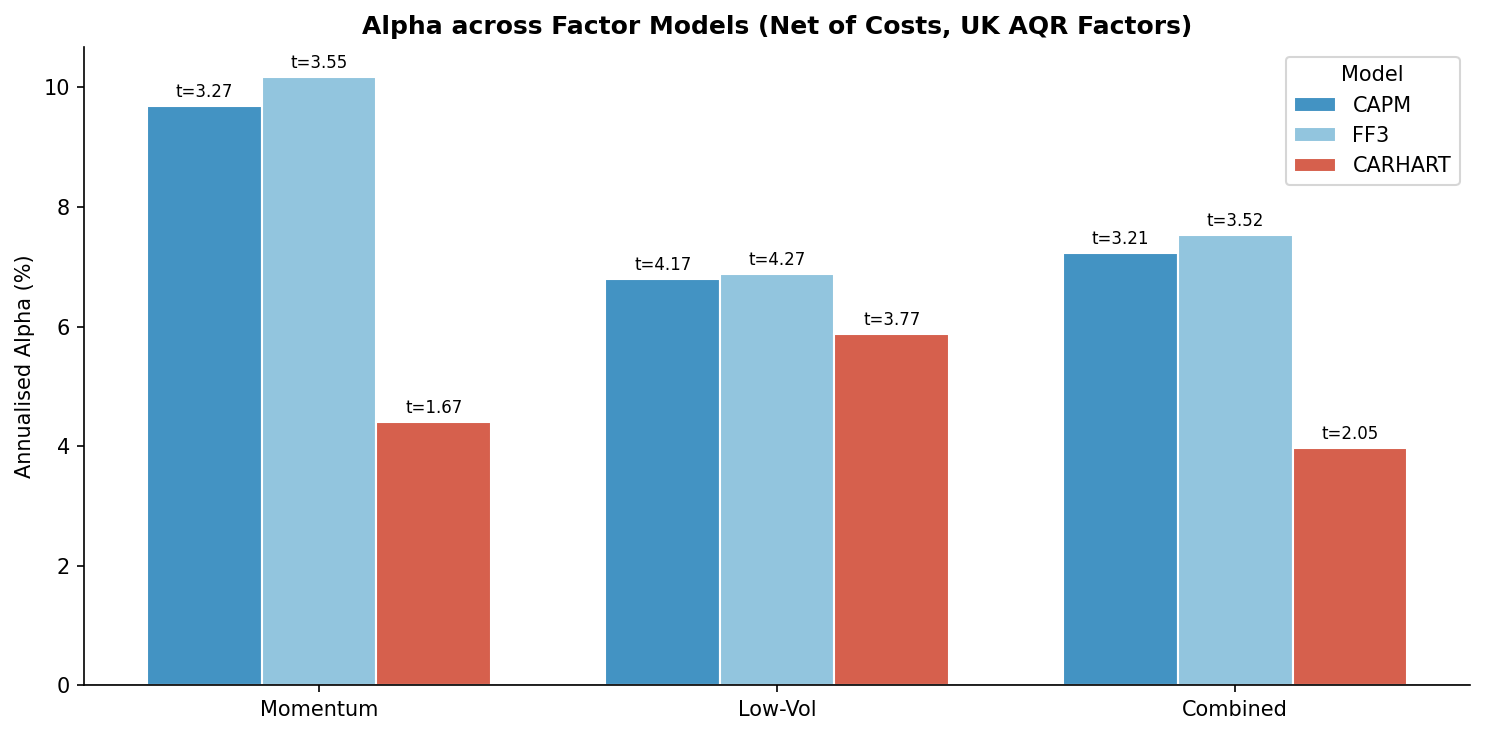

Saved: factor_attribution_alpha.png


In [13]:
# ── Alpha by model chart ──────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

strats   = ['Momentum', 'Low-Vol', 'Combined']
models   = ['CAPM', 'FF3', 'CARHART']
model_cs = {'CAPM': '#4393c3', 'FF3': '#92c5de', 'CARHART': '#d6604d'}

x = np.arange(len(strats))
w = 0.25

for i, model in enumerate(models):
    alphas = [
        next(r['alpha'] for r in results if r['strategy'] == s and r['model'] == model) * 100
        for s in strats
    ]
    ts = [
        next(r['alpha_t'] for r in results if r['strategy'] == s and r['model'] == model)
        for s in strats
    ]
    bars = ax.bar(x + (i-1)*w, alphas, w, label=model, color=model_cs[model], edgecolor='white')
    for bar, t in zip(bars, ts):
        h    = bar.get_height()
        ypos = h + 0.15 if h >= 0 else h - 0.4
        ax.text(bar.get_x() + bar.get_width()/2, ypos, f't={t:.2f}',
                ha='center', fontsize=8)

ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(strats)
ax.set_ylabel('Annualised Alpha (%)')
ax.set_title('Alpha across Factor Models (Net of Costs, UK AQR Factors)', fontweight='bold')
ax.legend(title='Model', loc='upper right')

plt.tight_layout()
plt.savefig(DATA_OUT / 'factor_attribution_alpha.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: factor_attribution_alpha.png')

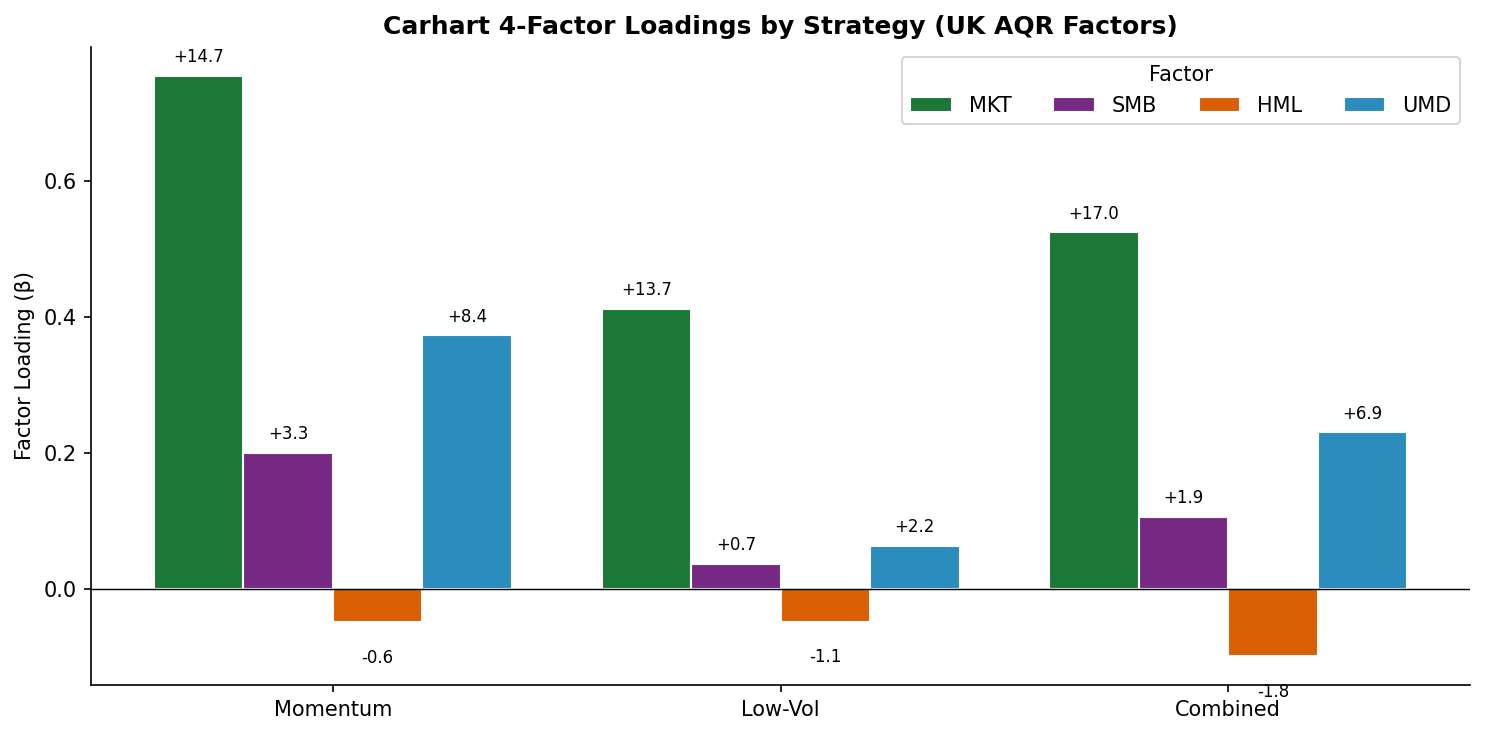

Saved: factor_attribution_betas.png


In [14]:
# ── Beta loadings (Carhart 4-factor) chart ────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

factor_names = ['MKT', 'SMB', 'HML', 'UMD']
factor_cs    = {'MKT': '#1b7837', 'SMB': '#762a83', 'HML': '#d95f02', 'UMD': '#2b8cbe'}

x = np.arange(len(strats))
w = 0.20

for i, fac in enumerate(factor_names):
    betas = [
        next(r[f'beta_{fac}'] for r in results if r['strategy'] == s and r['model'] == 'CARHART')
        for s in strats
    ]
    ts = [
        next(r[f'tstat_{fac}'] for r in results if r['strategy'] == s and r['model'] == 'CARHART')
        for s in strats
    ]
    bars = ax.bar(x + (i-1.5)*w, betas, w, label=fac, color=factor_cs[fac], edgecolor='white')
    for bar, t in zip(bars, ts):
        h    = bar.get_height()
        ypos = h + 0.02 if h >= 0 else h - 0.06
        ax.text(bar.get_x() + bar.get_width()/2, ypos, f'{t:+.1f}',
                ha='center', fontsize=8)

ax.axhline(0, color='black', linewidth=0.7)
ax.set_xticks(x)
ax.set_xticklabels(strats)
ax.set_ylabel('Factor Loading (β)')
ax.set_title('Carhart 4-Factor Loadings by Strategy (UK AQR Factors)', fontweight='bold')
ax.legend(title='Factor', ncol=4, loc='upper right')

plt.tight_layout()
plt.savefig(DATA_OUT / 'factor_attribution_betas.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: factor_attribution_betas.png')

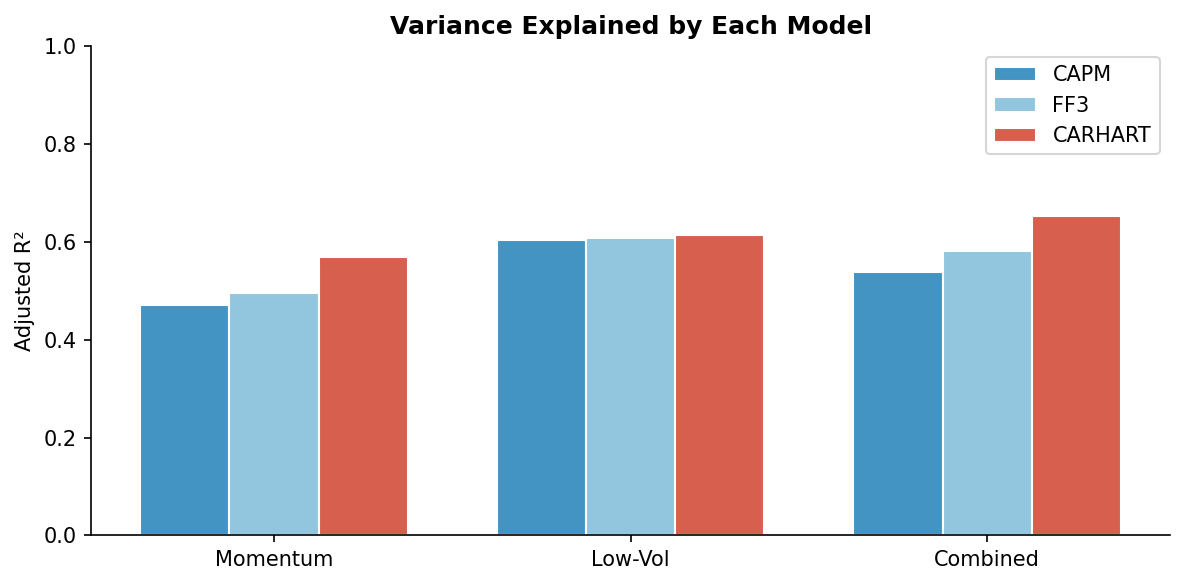

Saved: factor_attribution_r2.png


In [15]:
fig, ax = plt.subplots(figsize=(8, 4))

x = np.arange(len(strats))
w = 0.25

for i, model in enumerate(models):
    r2s = [
        next(r['r_sq_adj'] for r in results if r['strategy'] == s and r['model'] == model)
        for s in strats
    ]
    ax.bar(x + (i-1)*w, r2s, w, label=model, color=model_cs[model], edgecolor='white')

ax.set_xticks(x)
ax.set_xticklabels(strats)
ax.set_ylabel('Adjusted R²')
ax.set_title('Variance Explained by Each Model', fontweight='bold')
ax.legend(loc='upper right')
ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(DATA_OUT / 'factor_attribution_r2.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: factor_attribution_r2.png')

In [16]:
results_df.to_csv(DATA_OUT / 'factor_attribution_results.csv', index=False)
print('Saved: factor_attribution_results.csv')
print()
print('Files generated:')
print('  data/factor_attribution_results.csv')
print('  data/factor_attribution_alpha.png')
print('  data/factor_attribution_betas.png')
print('  data/factor_attribution_r2.png')

Saved: factor_attribution_results.csv

Files generated:
  data/factor_attribution_results.csv
  data/factor_attribution_alpha.png
  data/factor_attribution_betas.png
  data/factor_attribution_r2.png


In [6]:
print('factors_df shape:', factors_df.shape)
print('factors_df index type:', type(factors_df.index))
print('factors_df dtypes:\n', factors_df.dtypes)
print('factors_df head:')
print(factors_df.head())

factors_df shape: (0, 0)
factors_df index type: <class 'pandas.RangeIndex'>
factors_df dtypes:
 Series([], dtype: object)
factors_df head:
Empty DataFrame
Columns: []
Index: []
